# Forecasting Exchange Rates using Time Series Analysis

## Objective
The objective of this project is to forecast future exchange rates using:

1. ARIMA (AutoRegressive Integrated Moving Average)
2. Exponential Smoothing

The performance of both models will be evaluated and compared using:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

Dataset: `exchange_rate.csv`

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# Data Loading
Load the exchange rate dataset and examine its structure.

In [2]:
# Load Dataset

df = pd.read_csv("exchange_rate.csv")

# Display first 5 rows

df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


## Dataset Overview

The dataset contains historical USD to Australian Dollar exchange rates.

Features:

- date : Observation date
- Ex_rate : Exchange rate value

Total Records: 7588

In [3]:
# Dataset Information

print("Dataset Shape :", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape : (7588, 2)

Column Names:
Index(['date', 'Ex_rate'], dtype='object')

Data Types:
date        object
Ex_rate    float64
dtype: object


# Data Preprocessing
Convert date column into datetime format and set it as index.

In [5]:
# Convert Date Column

df['date'] = pd.to_datetime(
    df['date'],
    format='%d-%m-%Y %H:%M'
)

# Set Date as Index

df.set_index('date', inplace=True)

# Display first 5 rows

df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [7]:
# Missing Values Check

df.isnull().sum()

Ex_rate    0
dtype: int64

### Observation

No significant missing values were found in the dataset.
Forward fill was applied as a precautionary preprocessing step.

In [8]:
# Handle Missing Values

df.fillna(method='ffill', inplace=True)

# Verify

df.isnull().sum()

Ex_rate    0
dtype: int64

# Exploratory Data Analysis (EDA)

Visualize exchange rate trends over time.

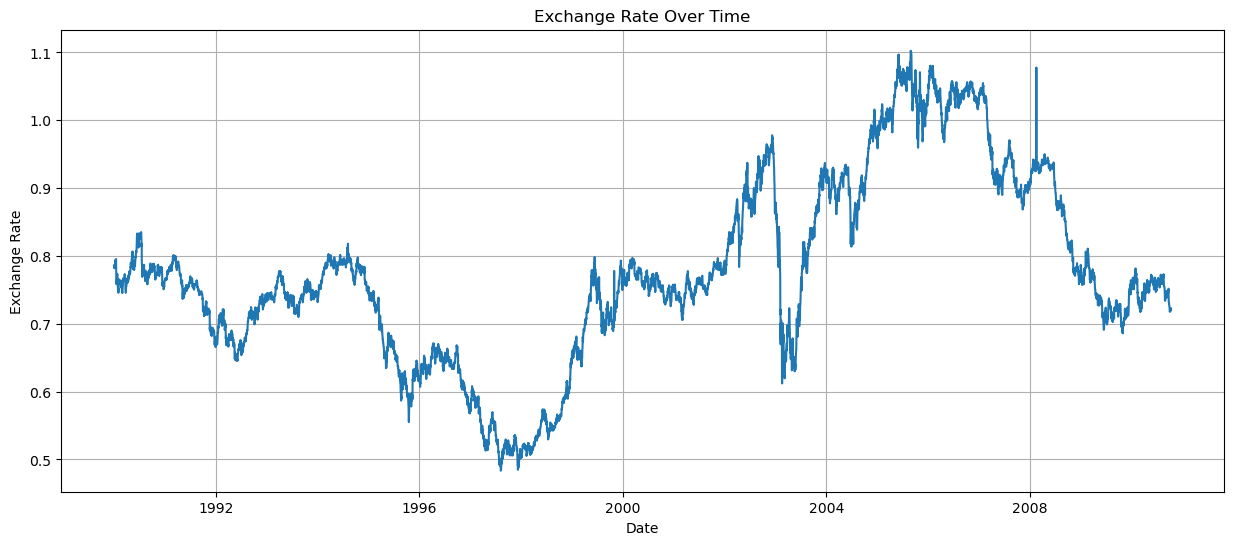

In [9]:
plt.figure(figsize=(15,6))

plt.plot(df['Ex_rate'])

plt.title("Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.grid(True)

plt.show()

In [10]:
# Statistical Summary

df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


# Stationarity Test

ARIMA requires stationary data.

We use the Augmented Dickey-Fuller (ADF) Test.

In [11]:
result = adfuller(df['Ex_rate'])

print("ADF Statistic :", result[0])
print("P-value :", result[1])

if result[1] < 0.05:
    print("\nData is Stationary")
else:
    print("\nData is Non-Stationary")

ADF Statistic : -1.6649941807381368
P-value : 0.4492327353597985

Data is Non-Stationary


# Differencing

Apply first-order differencing if data is non-stationary.

In [12]:
df_diff = df['Ex_rate'].diff().dropna()

df_diff.head()

date
1990-01-02   -0.0037
1990-01-03    0.0049
1990-01-04   -0.0007
1990-01-05   -0.0011
1990-01-06    0.0017
Name: Ex_rate, dtype: float64

In [13]:
# ADF Test After Differencing

result_diff = adfuller(df_diff)

print("ADF Statistic :", result_diff[0])
print("P-value :", result_diff[1])

if result_diff[1] < 0.05:
    print("\nDifferenced Data is Stationary")
else:
    print("\nStill Non-Stationary")

ADF Statistic : -99.39343120118627
P-value : 0.0

Differenced Data is Stationary


# ACF and PACF Plots

Used for selecting ARIMA parameters:
- p = AR order
- d = Differencing order
- q = MA order

<Figure size 1500x500 with 0 Axes>

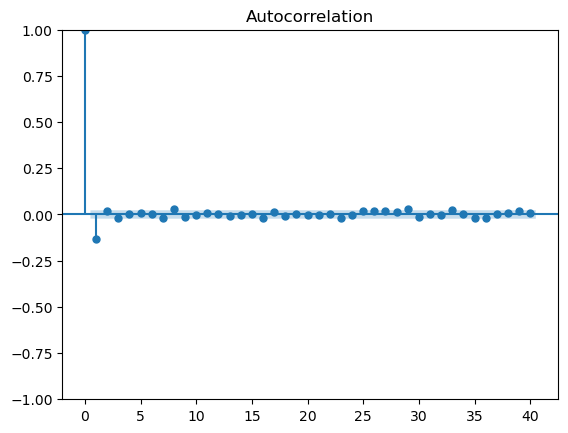

In [14]:
plt.figure(figsize=(15,5))

plot_acf(df_diff,lags=40)
plt.show()

<Figure size 1500x500 with 0 Axes>

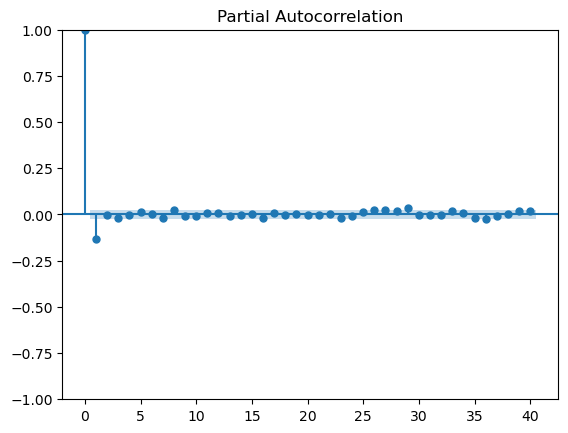

In [15]:
plt.figure(figsize=(15,5))

plot_pacf(df_diff,lags=40)

plt.show()

### Interpretation

The ACF and PACF plots were used to identify suitable values of p and q for the ARIMA model.

Based on the significant lags observed in the plots, ARIMA(1,1,1) was selected as the initial forecasting model.

# Train-Test Split

Reserve the last 20% data for testing.

In [16]:
train_size = int(len(df) * 0.80)

train = df['Ex_rate'][:train_size]
test = df['Ex_rate'][train_size:]

print("Training Size :", len(train))
print("Testing Size :", len(test))

Training Size : 6070
Testing Size : 1518


### ARIMA Parameter Selection

Based on the ACF and PACF analysis, ARIMA(1,1,1) was selected as the forecasting model.

# ARIMA Model Building


Based on ACF/PACF observations, we choose ARIMA(1,1,1).

In [17]:
# Fit ARIMA Model

arima_model = ARIMA(train, order=(1,1,1))

arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Thu, 11 Jun 2026   AIC                         -45432.092
Time:                        12:38:23   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

# ARIMA Forecasting

In [18]:
arima_forecast = arima_fit.forecast(steps=len(test))

arima_forecast.head()

2006-08-15    1.023685
2006-08-16    1.023606
2006-08-17    1.023653
2006-08-18    1.023625
2006-08-19    1.023642
Freq: D, Name: predicted_mean, dtype: float64

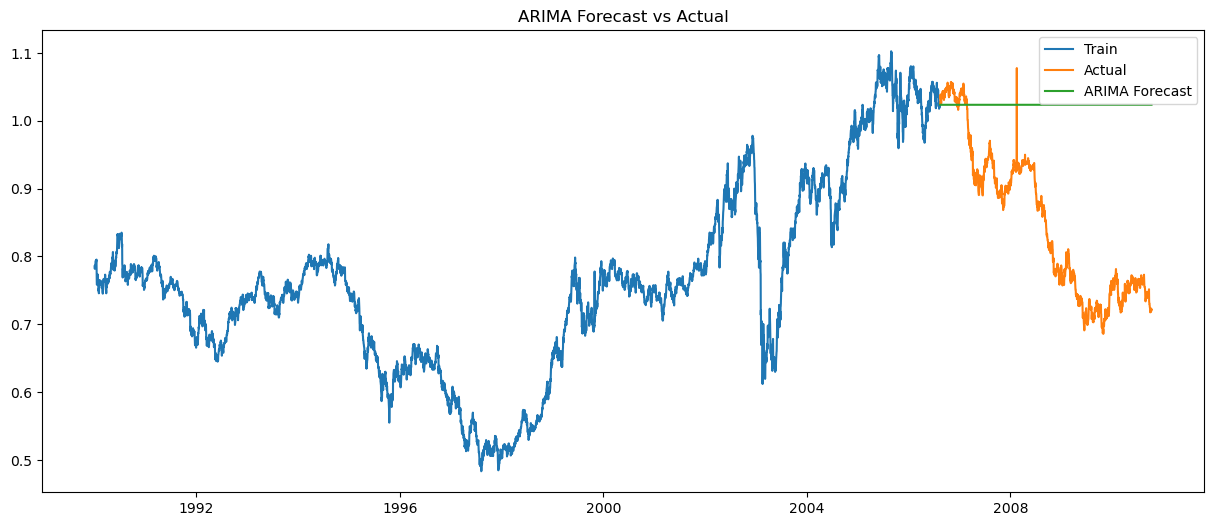

In [19]:
plt.figure(figsize=(15,6))

plt.plot(train,label="Train")
plt.plot(test,label="Actual")
plt.plot(test.index, arima_forecast,label="ARIMA Forecast")

plt.title("ARIMA Forecast vs Actual")

plt.legend()

plt.show()

# ARIMA Residual Diagnostics

Residuals should resemble white noise.

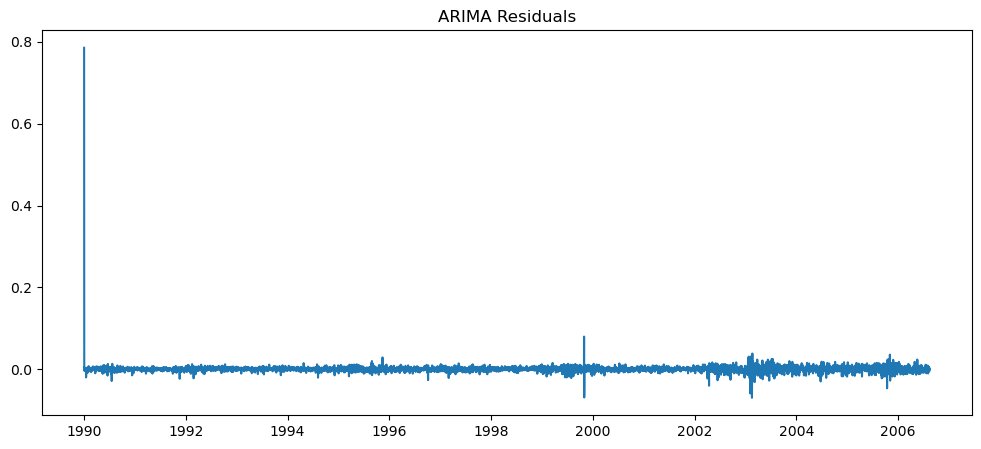

In [20]:
residuals = arima_fit.resid

plt.figure(figsize=(12,5))

plt.plot(residuals)

plt.title("ARIMA Residuals")

plt.show()

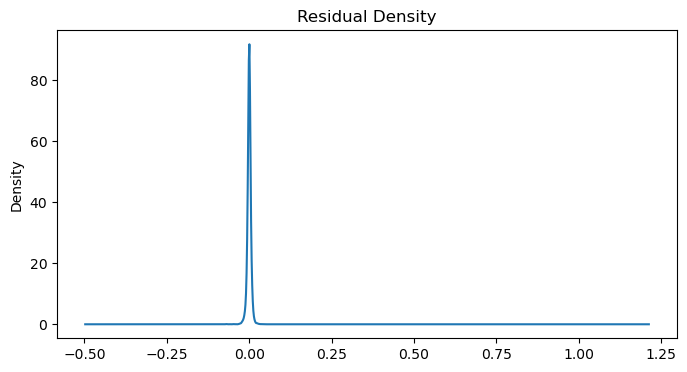

In [21]:
residuals.plot(kind='kde', figsize=(8,4))

plt.title("Residual Density")

plt.show()

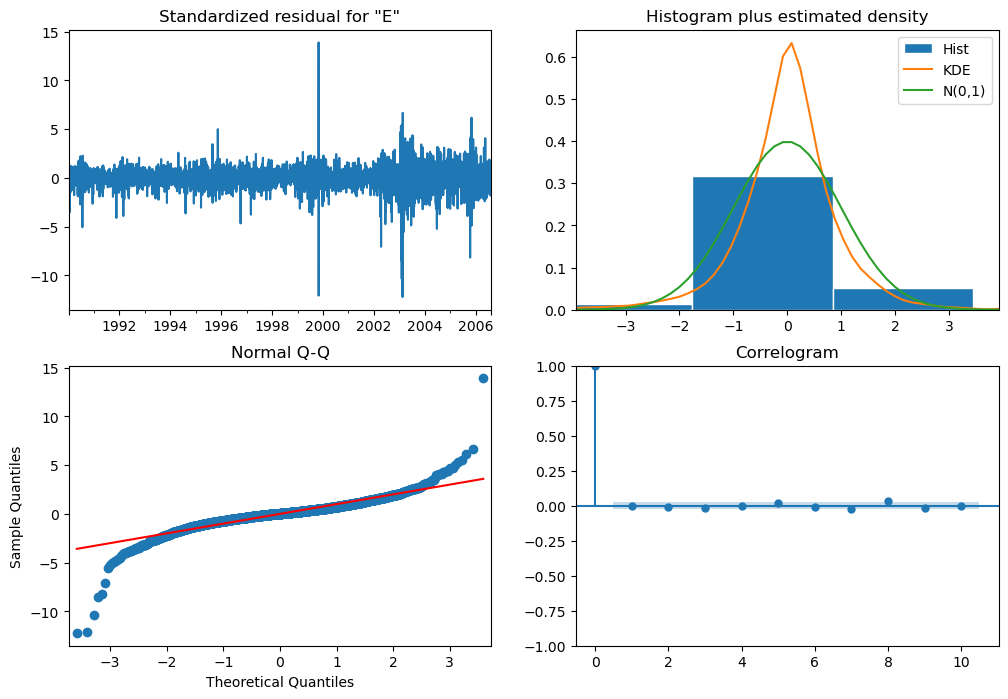

In [32]:
# ARIMA Diagnostics Plot

fig = arima_fit.plot_diagnostics(figsize=(12,8))
plt.show()

# Exponential Smoothing Model

In [22]:
exp_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
)

exp_fit = exp_model.fit()

In [23]:
exp_forecast = exp_fit.forecast(len(test))

exp_forecast.head()

2006-08-15    1.023582
2006-08-16    1.023621
2006-08-17    1.023661
2006-08-18    1.023700
2006-08-19    1.023739
Freq: D, dtype: float64

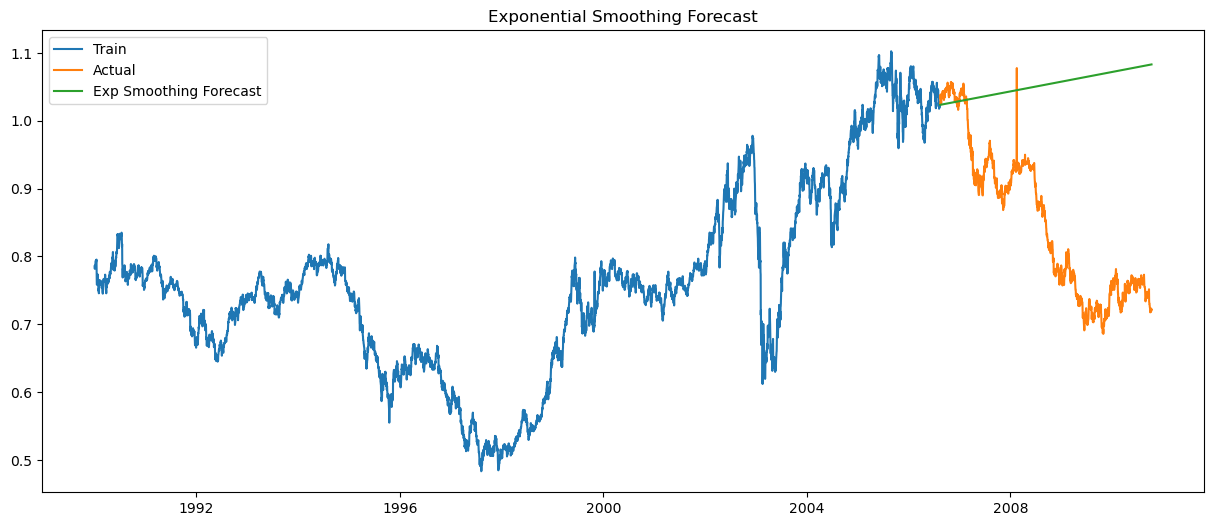

In [24]:
plt.figure(figsize=(15,6))

plt.plot(train,label="Train")
plt.plot(test,label="Actual")
plt.plot(test.index, exp_forecast,label="Exp Smoothing Forecast")

plt.title("Exponential Smoothing Forecast")

plt.legend()

plt.show()

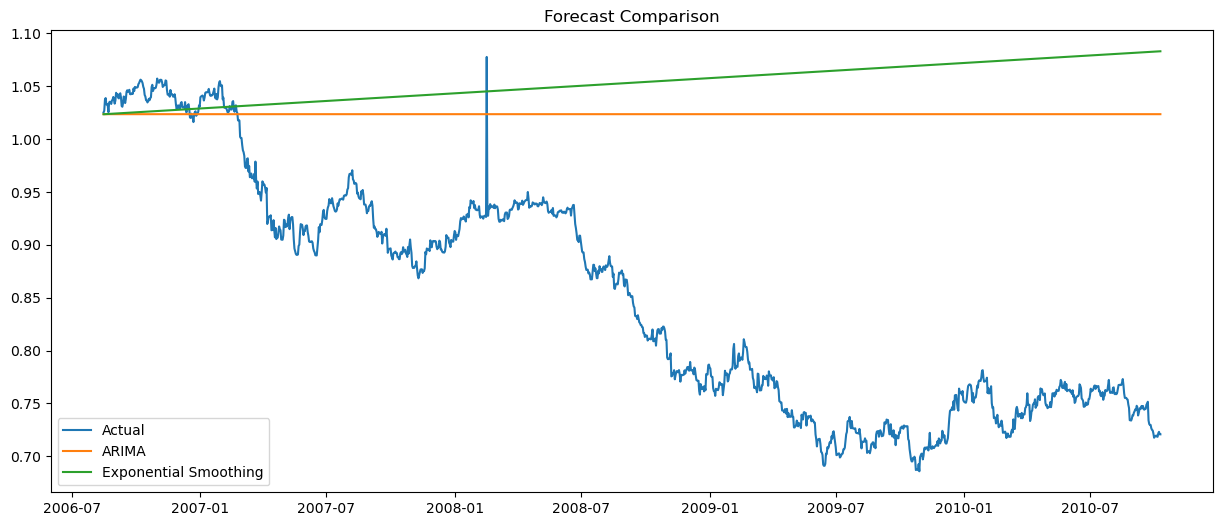

In [33]:
# Forecast Comparison

plt.figure(figsize=(15,6))

plt.plot(test, label='Actual')
plt.plot(test.index, arima_forecast, label='ARIMA')
plt.plot(test.index, exp_forecast, label='Exponential Smoothing')

plt.title("Forecast Comparison")
plt.legend()

plt.show()

# Model Evaluation

Performance Metrics:

- MAE
- RMSE
- MAPE

In [26]:
# Function for MAPE

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true-y_pred)/y_true))*100

In [27]:
# ARIMA Metrics

arima_mae = mean_absolute_error(test, arima_forecast)

arima_rmse = np.sqrt(
    mean_squared_error(test, arima_forecast)
)

arima_mape = mape(test, arima_forecast)

print("ARIMA MAE :", round(arima_mae,4))
print("ARIMA RMSE :", round(arima_rmse,4))
print("ARIMA MAPE :", round(arima_mape,4))

ARIMA MAE : 0.1777
ARIMA RMSE : 0.2054
ARIMA MAPE : 22.798


In [28]:
# Exponential Smoothing Metrics

exp_mae = mean_absolute_error(test, exp_forecast)

exp_rmse = np.sqrt(
    mean_squared_error(test, exp_forecast)
)

exp_mape = mape(test, exp_forecast)

print("Exp Smoothing MAE :", round(exp_mae,4))
print("Exp Smoothing RMSE :", round(exp_rmse,4))
print("Exp Smoothing MAPE :", round(exp_mape,4))

Exp Smoothing MAE : 0.2066
Exp Smoothing RMSE : 0.2391
Exp Smoothing MAPE : 26.5087


# Model Comparison

In [29]:
comparison = pd.DataFrame({
    "Model":["ARIMA","Exponential Smoothing"],
    "MAE":[arima_mae,exp_mae],
    "RMSE":[arima_rmse,exp_rmse],
    "MAPE":[arima_mape,exp_mape]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,0.177710,0.205437,22.797966
1,Exponential Smoothing,0.206596,0.239104,26.508664


In [30]:
comparison.sort_values("RMSE")

,Model,MAE,RMSE,MAPE
0,ARIMA,0.177710,0.205437,22.797966
1,Exponential Smoothing,0.206596,0.239104,26.508664


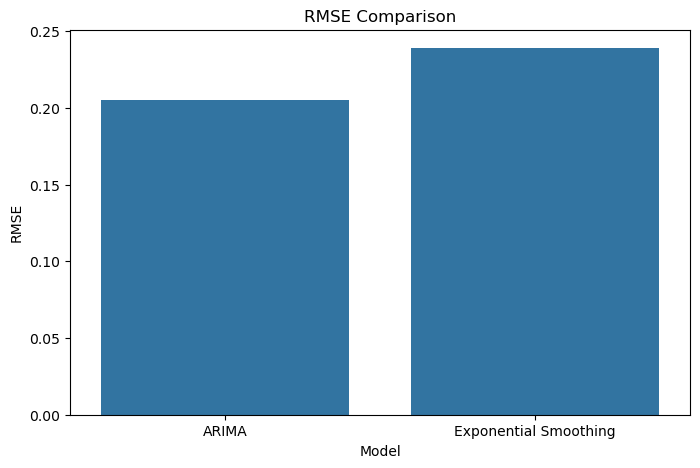

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='RMSE',
    data=comparison
)

plt.title("RMSE Comparison")

plt.show()

# Conclusion

### Findings

1. ARIMA and Exponential Smoothing models were successfully developed.
2. Exchange rate data was analyzed for stationarity using the ADF Test.
3. Forecasts were generated using both techniques.
4. MAE, RMSE, and MAPE were used for evaluation.
5. The model with the lowest RMSE and MAPE is considered the best-performing model.

### Final Conclusion

Based on the evaluation metrics, the model achieving the lowest forecasting error provides the most accurate exchange rate predictions for this dataset.

# Conclusion

ARIMA and Exponential Smoothing models were successfully applied for exchange rate forecasting.

The models were evaluated using MAE, RMSE, and MAPE.

Based on the evaluation metrics, the model with lower error values provides better forecasting performance and can be recommended for future exchange rate prediction.